In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import pyreadr
import joblib
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import plotly.express as px

from tqdm import tqdm

from dash import Dash, html, dcc, dash_table, Input, Output, callback
import dash_bootstrap_components as dbc

In [3]:
pd.set_option('display.max_columns', 100)

In [4]:
dem_uncont = 34
rep_uncont = 31

In [5]:
seat_sims = pyreadr.read_r('model_output/tot_seats_sims.RDS')[None]
seat_sims = seat_sims.rename({None: 'seats'}, axis=1)
seat_sims['seats'] = seat_sims['seats'].map(lambda x: x + dem_uncont)
seat_sims['winner'] = seat_sims['seats'].map(lambda x: 'Democrats' if x >= 51 else 'Republicans')
seat_sims

,seats,winner
0,54,Democrats
1,55,Democrats
2,49,Republicans
3,54,Democrats
4,48,Republicans
...,...,...
7995,51,Democrats
7996,52,Democrats
7997,53,Democrats
7998,51,Democrats


In [6]:
sim_counts = seat_sims.groupby(['seats']).count().reset_index().rename({'winner': 'count'}, axis=1)
n_sims = seat_sims.shape[0]
sim_counts['pct'] = sim_counts['count'] / n_sims * 100
sim_counts['winner'] = sim_counts['seats'].map(lambda x: 'Democrats' if x >= 51 else 'Republicans')
seat_sims = pd.merge(left=seat_sims.drop(['winner'], axis=1), right=sim_counts, on='seats', how='left')
def get_desc(winner, pct, seats):
    return f'{winner} wins {seats if seats >= 51 else (100-seats)} seats in {pct:.2f}% of simulations'
#seat_sims['desc'] = seat_sims[['winner', 'pct', 'seats']].apply(lambda x: get_desc(x['winner'], x['pct'], x['seats']), axis=1)
sim_counts.head()

,seats,count,pct,winner
0,37,1,0.0125,Republicans
1,38,1,0.0125,Republicans
2,41,5,0.0625,Republicans
3,42,14,0.1750,Republicans
4,43,59,0.7375,Republicans


In [7]:
np.unique(seat_sims['seats']).shape[0]

25

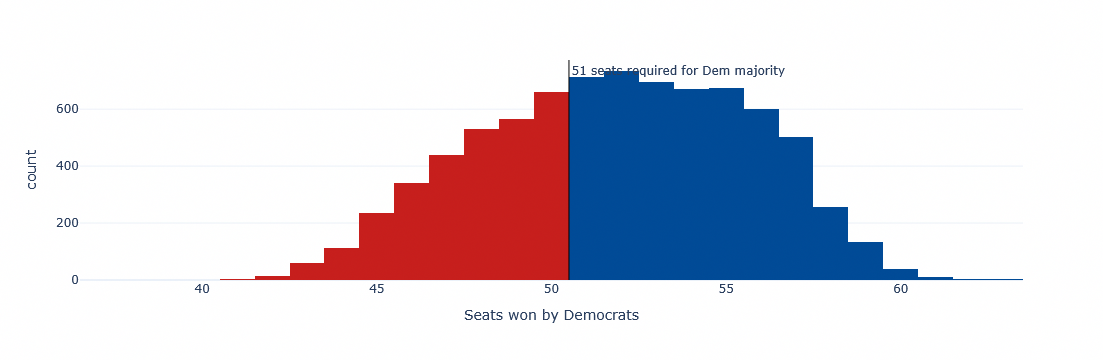

In [8]:
sims_hist = px.histogram(seat_sims, x='seats', nbins=np.unique(seat_sims['seats']).shape[0]*2, color='winner',
                         color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},
                         labels={'seats':'Seats won by Democrats', 'winner': 'Winner'}, template='plotly_white')
sims_hist.update_traces(showlegend=False)
sims_hist.add_vline(x=50.5, line_width=1, line_color='black', annotation_text='51 seats required for Dem majority', 
                    annotation_position='top right')
sims_hist

In [9]:
output_ts = pd.read_csv('model_output/output_over_time.csv')
output_ts.head()

,date,y,geo,type
0,2026-09-27,51.348375,US Senate,seats
1,2026-09-27,58.600000,US Senate,chance
2,2026-09-27,3.816193,US Senate,seats_sd
3,2026-09-27,38.771876,AL,y_pred
4,2026-09-27,3.537242,AL,y_pred_sd


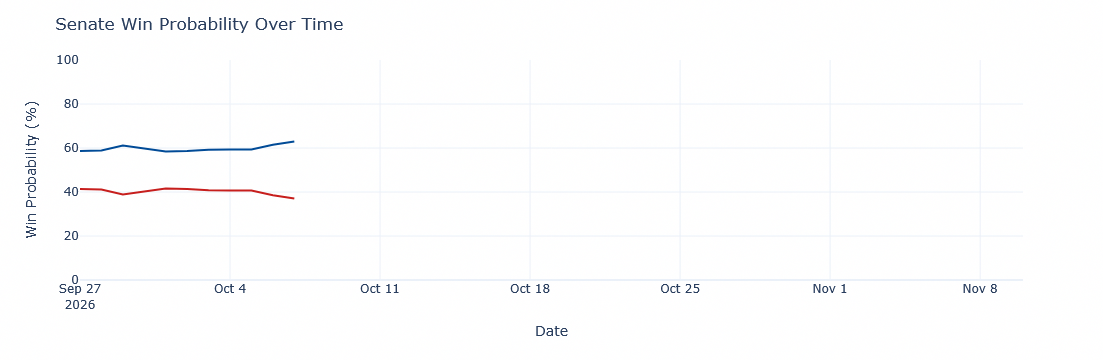

In [10]:
chance_over_time = output_ts[(output_ts['geo'] == 'US Senate') &
                             (output_ts['type'] == 'chance')]
chance_over_time['rep_chance'] = chance_over_time['y'].map(lambda x: 100 - x)
chance_over_time = chance_over_time.rename({'y': 'Democrats', 'rep_chance': 'Republicans'}, axis=1)
chance_time_ser = px.line(chance_over_time, x='date', y=['Democrats', 'Republicans'], template='plotly_white',
                         color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},)
chance_time_ser.update_traces(hovertemplate="%{y:.1f}%")
chance_time_ser.update_layout(
    xaxis=dict(range=[pd.to_datetime('2026-09-27'), pd.to_datetime('2026-11-10')]),
    yaxis=dict(range=[0, 100]),
    xaxis_title='Date',
    yaxis_title='Win Probability (%)',
    title=dict(text="Senate Win Probability Over Time"),
    hovermode="x",
    showlegend=False
)
chance_time_ser

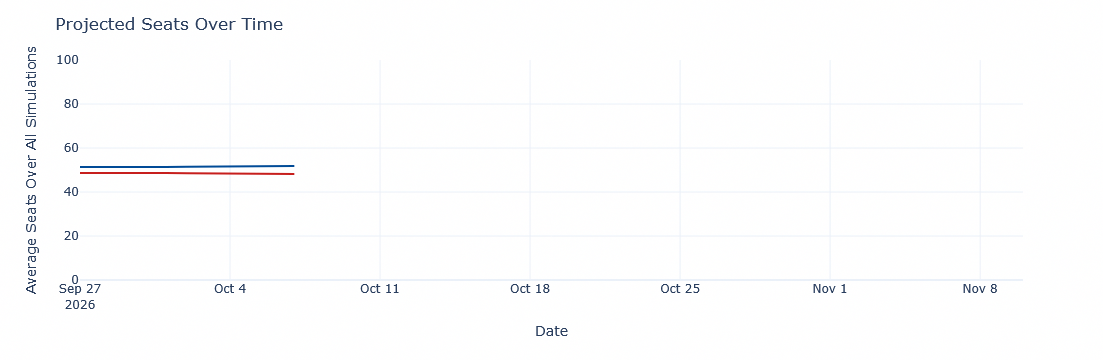

In [11]:
seats_over_time = output_ts[(output_ts['geo'] == 'US Senate') &
                             (output_ts['type'] == 'seats')]
seats_over_time['rep_seats'] = seats_over_time['y'].map(lambda x: 100 - x)
seats_over_time = seats_over_time.rename({'y': 'Democrats', 'rep_seats': 'Republicans'}, axis=1)
seats_time_ser = px.line(seats_over_time, x='date', y=['Democrats', 'Republicans'], template='plotly_white',
                        color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},)
seats_time_ser.update_traces(hovertemplate="%{y:.1f}")
seats_time_ser.update_layout(
    xaxis=dict(range=[pd.to_datetime('2026-09-27'), pd.to_datetime('2026-11-10')]),
    yaxis=dict(range=[0, 100]),
    xaxis_title='Date',
    yaxis_title='Average Seats Over All Simulations',
    title=dict(text="Projected Seats Over Time"),
    hovermode="x",
    showlegend=False
)
seats_time_ser

In [12]:
joblib.dump(sims_hist, 'display_data/sims_histogram.pkl')
joblib.dump(chance_time_ser, 'display_data/chance_time_ser.pkl')
joblib.dump(seats_time_ser, 'display_data/seats_time_ser.pkl')

['display_data/seats_time_ser.pkl']

In [13]:
# posterior prediction
post = pyreadr.read_r('model_output/labeled_posterior.RDS')[None]
post_untransp = post.copy()

In [14]:
post = post.T
post.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,...,7950,7951,7952,7953,7954,7955,7956,7957,7958,7959,7960,7961,7962,7963,7964,7965,7966,7967,7968,7969,7970,7971,7972,7973,7974,7975,7976,7977,7978,7979,7980,7981,7982,7983,7984,7985,7986,7987,7988,7989,7990,7991,7992,7993,7994,7995,7996,7997,7998,7999
AL,-7.877874,-13.946968,-12.138374,-12.177777,-9.859175,-13.701391,-11.727903,-5.580214,-12.661782,-17.611765,-1.403392,-13.576634,-11.412530,-11.870912,-12.440474,-9.554521,-9.862104,-12.866491,-10.274061,-7.768014,-13.157774,-9.072255,-7.248865,-9.622882,-9.309675,-14.488748,-14.068214,-8.429119,-13.305603,-13.120847,-10.608344,-12.179223,-11.834491,-8.338169,-16.360017,-15.367397,-8.178672,-11.137912,-9.019059,-12.848395,-10.854238,-9.151937,-14.260053,-10.871728,-13.107701,-13.593702,-13.206126,-15.434941,-7.949136,-11.780108,...,-11.918671,-11.213714,-10.361397,-15.409650,-7.618069,-11.736051,-13.304769,-8.178836,-12.655782,-8.499806,-16.509548,-16.544226,-10.847732,-7.543616,-17.749537,-7.407498,-16.660025,-3.378927,-12.622015,-8.879818,-11.904355,-10.259880,-4.642167,-21.844267,-3.290157,-14.697406,-12.235090,-13.561327,-8.538148,-12.617841,-11.198944,-12.892626,-11.288072,-8.294720,-16.981929,-12.802985,-11.410872,-19.024731,-10.657295,-10.172432,-11.009999,-14.585616,-10.799470,-10.704644,-12.474748,-13.542200,-15.165524,-10.269052,-12.967023,-12.489176
AK,0.703676,5.863048,0.097203,5.778374,-0.704672,4.846592,5.261080,5.573063,-0.319852,-5.396555,11.110805,0.544456,-0.910717,6.682779,-0.541091,3.447493,5.934574,4.950361,-0.144189,3.060567,7.056518,4.489454,2.589071,5.279340,4.973124,1.759764,2.700060,3.761127,-0.707614,1.941623,3.749126,5.939793,7.225093,8.494433,3.125937,0.104687,3.801047,0.357107,-0.799837,3.488078,-0.961613,3.832999,7.188226,4.371672,2.832168,-1.440631,1.148711,3.203972,2.520958,4.555247,...,4.196962,3.193228,10.234047,-0.194834,7.768443,2.998086,1.356971,3.758144,-1.234033,10.676260,2.573364,-0.696378,7.211344,3.474074,4.031752,1.764073,5.144568,2.287642,-0.511918,7.725031,1.788624,3.486920,8.789966,0.271103,4.324974,-2.311099,6.439430,5.251384,3.677615,1.200760,-3.005489,5.568735,-0.618734,6.121996,2.032047,3.175185,3.415425,7.489311,4.188592,4.191482,0.312019,4.464428,4.034024,0.612814,4.297390,0.924860,1.896490,0.734985,3.815640,1.906513
AR,-11.291516,-13.044305,-9.430891,-12.102786,-10.890986,-9.105227,-10.139699,-6.687551,-15.332162,-15.037786,-2.282480,-12.811230,-13.679344,-8.177641,-13.157307,-11.799104,-11.133470,-9.640281,-12.010162,-8.346723,-12.330003,-11.772442,-8.110078,-8.273270,-12.519698,-9.923608,-12.352345,-8.998832,-12.339423,-12.108878,-9.473146,-10.208933,-7.613378,-8.371179,-14.554361,-14.017674,-7.282618,-10.824648,-12.342365,-11.419476,-11.474657,-7.354235,-13.142872,-14.994365,-13.637007,-11.833457,-9.956957,-14.938270,-11.843122,-12.792154,...,-13.833929,-12.470336,-9.108844,-14.447948,-4.844643,-13.300004,-13.669926,-12.404254,-11.260476,-4.958185,-15.603661,-13.188091,-9.210656,-8.558280,-14.495856,-5.690177,-16.455083,-2.164977,-10.304405,-9.564877,-12.852493,-7.359206,-5.875419,-16.492123,-4.338129,-17.481766,-10.140010,-17.153968,-6.290086,-10.746098,-10.161816,-11.876471,-10.603838,-3.457640,-18.526714,-10.629748,-8.661358,-13.413370,-7.050293,-13.088688,-12.139254,-11.703544,-9.588973,-8.143789,-12.304652,-14.328200,-17.968850,-12.259380,-8.706240,-11.782189
CO,11.603984,12.384743,7.458018,14.310056,9.064779,12.746506,14.550180,13.440394,11.015976,7.340552,13.509208,13.995981,11.112348,16.375831,8.124788,15.856093,13.913956,11.997895,7.009362,6.276469,13.136180,18.892624,10.098944,16.635178,13.887038,11.681433,11.507445,20.257760,7.924330,13.720260,14.279640,10.661144,9.577789,10.683623,11.963342,6.010962,16.517724,11.406492,15.622429,9.408952,13.252024,12.231886,11.864039,13.802335,10.798729,11.935592,7.852508,11.317099,12.594650,9.738585,...,14.011627,8.842272,17.614751,10.

In [15]:
sim_corr = post_untransp.corr()

In [16]:
sim_corr.head()

,AL,AK,AR,CO,DE,FL,GA,ID,IL,IA,KS,KY,LA,ME,MA,MI,MN,MS,MT,NE,NH,NJ,NM,NC,OH,OK,OR,RI,SC,SD,TN,TX,VA,WV,WY
AL,1.000000,0.516388,0.740082,0.490245,0.497253,0.706601,0.531885,0.737204,0.705979,0.744139,0.737736,0.541078,0.751791,0.735998,0.523236,0.734543,0.708739,0.743846,0.702344,0.725028,0.502892,0.506885,0.506428,0.705668,0.507068,0.758504,0.507769,0.490839,0.491643,0.512001,0.557500,0.701829,0.506599,0.741264,0.739059
AK,0.516388,1.000000,0.516613,0.520648,0.524666,0.499163,0.558112,0.526754,0.505221,0.517678,0.519190,0.566153,0.523617,0.505218,0.560446,0.511122,0.499385,0.516768,0.498674,0.516586,0.561921,0.538881,0.554186,0.498063,0.552274,0.520747,0.546952,0.549455,0.538277,0.541562,0.597598,0.508834,0.543981,0.520411,0.519366
AR,0.740082,0.516613,1.000000,0.487473,0.499996,0.703708,0.527790,0.736342,0.699039,0.741355,0.737519,0.537160,0.742279,0.729717,0.523805,0.728889,0.700661,0.725887,0.694331,0.721475,0.509009,0.500474,0.501626,0.705721,0.504626,0.744306,0.501841,0.497067,0.495455,0.515391,0.557065,0.701777,0.498886,0.735951,0.735073
CO,0.490245,0.520648,0.487473,1.000000,0.708957,0.653807,0.550476,0.497600,0.652980,0.503182,0.487054,0.549405,0.503929,0.483653,0.538107,0.486902,0.642988,0.493866,0.653812,0.477377,0.710074,0.715797,0.719401,0.647741,0.705538,0.499909,0.710493,0.702457,0.699041,0.530794,0.571433,0.655971,0.703963,0.496865,0.494062
DE,0.497253,0.524666,0.499996,0.708957,1.000000,0.667437,0.542990,0.504065,0.663956,0.508839,0.499838,0.547761,0.503501,0.500236,0.549102,0.501253,0.663454,0.499234,0.664888,0.489307,0.718609,0.725939,0.728352,0.661562,0.715609,0.515672,0.710041,0.712829,0.709252,0.521152,0.577949,0.661521,0.719022,0.499431,0.509316


In [17]:
post.shape

(35, 8000)

In [18]:
def get_tipping_point(sim):
    """
    :param sim: Series representing one posterior draw or "simulation"
    :type sim: pd.Series
    """
    seats_won_dem = np.sum(sim > 0)
    if seats_won_dem >= 51 - dem_uncont: # Democrats win House in this draw
        sim = sim.sort_values(ascending=True)
        won_seats = sim[sim > 0]
        seat_margin = seats_won_dem - (51 - dem_uncont)
    else: # Republicans win House in this draw
        sim = sim.sort_values(ascending=False)
        won_seats = sim[sim < 0]
        seat_margin = (100 - seats_won_dem - dem_uncont - rep_uncont) - (50 - rep_uncont)
    return won_seats.iloc[seat_margin - 1], won_seats.index[seat_margin - 1]

In [19]:
tipping_points = np.array([]) # tipping point for *each sim*

for i in tqdm(range(post.shape[1])):
    sim = post.iloc[:, i]
    _, tp_seat = get_tipping_point(sim)
    tipping_points = np.append(tipping_points, tp_seat)

tipping_points

100%|████████████████████████████████████████████████████████████████████████████| 8000/8000 [00:05<00:00, 1527.53it/s]


array(['IA', 'MI', 'MN', ..., 'IA', 'MA', 'AK'],
      shape=(8000,), dtype='<U32')

In [20]:
data = pd.read_csv('../../model_output/senate_predictions.csv')
data.head()

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.245999,0,0,32.999181,0.542362,53.994266,0.542362,East South Central,2026,0.000000,0.0,0.000000,5,Senate,0.142508,0.542362,0.736452,20.995085,-20.380443,-49.622498,0,-99.244996,38.702629,3.539980,0.0500,1,31.890478,45.774492
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.245999,0,1,50.129501,3.479917,48.295887,3.479917,Pacific,2026,0.000000,0.0,0.000000,5,Senate,9989.631483,3.479917,1.865454,-1.833614,-3.664605,49.948144,-1,99.896288,53.382142,3.407415,83.9625,2,46.705823,60.223546
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.245999,0,1,38.189521,0.342682,49.190029,0.342682,West South Central,2026,0.000000,0.0,0.000000,5,Senate,1718.789084,0.342682,0.585391,11.000508,-21.375044,-8.541719,-1,-17.083438,39.157982,3.567913,0.1250,3,32.057767,46.058174
3,3,Colorado,John Hickenlooper,Mark Baisley,True,False,D,CO,"HICKENLOOPER, JOHN W.","BAISLEY, MARK",5806791.50,134872.30,5941663.80,97.730058,2.269942,5.964568,55.646542,73.317129,2.765032,16.968086,3.741915,0.400190,45.698090,4966936,806778,5773714,86.026707,13.973293,0.987401,-9.245999,1,0,0.000000,0.000000,0.000000,0.000000,Mountain,2026,0.367879,0.0,0.367879,0,Senate,9551.164309,0.000000,0.000000,0.000000,21.175135,47.730058,1,95.460117,61.957507,3.504049,99.9625,4,55.169436,68.862074
4,4,Delaware,Chris Coons,Michael Katz,True,False,D,DE,"COONS, CHRISTOPHER A.","KATZ, MICHAEL S DR.",1989694.63,29805.27,2019499.90,98.524126,1.475874,8.011194,57.479236,66.185281,3.007143,6.848324,21.107845,0.148276,35.764628,817817,172131,989948,82.612117,17.387883,0.987401,-9.245999,1,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.000000,0.0,0.000000,2,Senate,9707.003443,0.000000,0.000000,0.000000,25.268388,48.524126,1,97.048252,63.500733,3.504492,99.9875,5,56.661193,70.458049


In [21]:
data['tipping_point_prob'] = data['state_po'].map(lambda x: np.mean(tipping_points == x) * 100)
data.head()

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.245999,0,0,32.999181,0.542362,53.994266,0.542362,East South Central,2026,0.000000,0.0,0.000000,5,Senate,0.142508,0.542362,0.736452,20.995085,-20.380443,-49.622498,0,-99.244996,38.702629,3.539980,0.0500,1,31.890478,45.774492,0.0000
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.245999,0,1,50.129501,3.479917,48.295887,3.479917,Pacific,2026,0.000000,0.0,0.000000,5,Senate,9989.631483,3.479917,1.865454,-1.833614,-3.664605,49.948144,-1,99.896288,53.382142,3.407415,83.9625,2,46.705823,60.223546,5.0625
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.245999,0,1,38.189521,0.342682,49.190029,0.342682,West South Central,2026,0.000000,0.0,0.000000,5,Senate,1718.789084,0.342682,0.585391,11.000508,-21.375044,-8.541719,-1,-17.083438,39.157982,3.567913,0.1250,3,32.057767,46.058174,0.0000
3,3,Colorado,John Hickenlooper,Mark Baisley,True,False,D,CO,"HICKENLOOPER, JOHN W.","BAISLEY, MARK",5806791.50,134872.30,5941663.80,97.730058,2.269942,5.964568,55.646542,73.317129,2.765032,16.968086,3.741915,0.400190,45.698090,4966936,806778,5773714,86.026707,13.973293,0.987401,-9.245999,1,0,0.000000,0.000000,0.000000,0.000000,Mountain,2026,0.367879,0.0,0.367879,0,Senate,9551.164309,0.000000,0.000000,0.000000,21.175135,47.730058,1,95.460117,61.957507,3.504049,99.9625,4,55.169436,68.862074,0.1125
4,4,Delaware,Chris Coons,Michael Katz,True,False,D,DE,"COONS, CHRISTOPHER A.","KATZ, MICHAEL S DR.",1989694.63,29805.27,2019499.90,98.524126,1.475874,8.011194,57.479236,66.185281,3.007143,6.848324,21.107845,0.148276,35.764628,817817,172131,989948,82.612117,17.387883,0.987401,-9.245999,1,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.000000,0.0,0.000000,2,Senate,9707.003443,0.000000,0.000000,0.000000,25.268388,48.524126,1,97.048252,63.500733,3.504492,99.9875,5,56.661193,70.458049,0.5250


In [22]:
data.sort_values('tipping_point_prob', ascending=False).head(5)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
9,9,Iowa,Josh Turek,Ashley Hinson,False,False,R,IA,"TUREK, JOSHUA","ARENHOLZ, ASHLEY HINSON",5835816.67,5267628.55,11103445.22,52.558612,47.441388,-6.092833,43.277201,88.847514,1.696738,4.401391,3.028533,0.168574,31.423453,2014831,1175538,3190369,63.153541,36.846459,0.987401,-9.245999,0,0,47.138291,6.032363,45.263464,6.032363,West North Central,2026,0.0,0.00000,0.00000,3,Senate,2762.407675,6.032363,2.456087,-1.874827,-2.939667,2.558612,0,5.117224,50.404679,3.516574,54.2000,10,43.407943,57.303912,10.7125
15,15,Michigan,Abdul El-Sayed,Mike J. Rogers,False,False,D,MI,"EL-SAYED, ABDUL","ROGERS, MICHAEL J",14408058.06,6831818.66,21239876.72,67.834942,32.165058,-0.192456,49.278763,77.709102,2.333008,4.148895,12.968600,0.319413,32.445883,7404258,2673073,10077331,73.474395,26.525605,0.987401,-9.245999,0,0,48.150050,9.693517,45.801667,9.693517,East North Central,2026,0.0,0.00000,0.00000,2,Senate,4601.579360,9.693517,3.113441,-2.348383,8.861087,17.834942,0,35.669884,50.272401,3.540202,53.0000,16,43.481570,57.283756,10.0375
31,31,Texas,James Talarico,Ken Paxton,False,False,R,TX,"TALARICO, JAMES","PAXTON, WARREN KENNETH JR.",65585741.88,9020177.98,74605919.86,87.909568,12.090432,-5.916874,43.060966,48.286718,4.530331,31.642337,13.173480,0.180615,33.823334,24400697,4744808,29145505,83.720275,16.279725,0.987401,-9.245999,0,0,49.038190,7.544942,44.845959,7.544942,West South Central,2026,0.0,0.25284,-0.25284,6,Senate,7728.092153,7.544942,2.746806,-4.192232,-2.587749,37.909568,0,75.819136,51.879791,3.630117,70.0250,32,44.803442,59.094961,9.7375
24,24,Ohio,Sherrod Brown,Jon Husted,False,True,R,OH,"BROWN, SHERROD","HUSTED, JON",31146133.40,6280012.05,37426145.45,83.220254,16.779746,-5.266554,44.343385,80.925356,1.708882,3.291326,11.486903,0.076606,31.487184,9001099,2798349,11799448,76.284069,23.715931,0.987401,-9.245999,0,1,48.922377,3.109720,44.698919,3.109720,East North Central,2026,0.0,0.00000,0.00000,2,Senate,6925.610718,3.109720,1.763440,-4.223457,-1.287108,33.220254,-1,66.440509,51.156560,3.467957,63.4875,25,44.255379,58.001811,9.0750
28,28,South Carolina,Annie Andrews,Darline Graham,False,False,R,SC,"ANDREWS, ANNIE","GRAHAM, DARLINE",10677209.93,299782.64,10976992.57,97.268991,2.731009,-8.282832,40.938317,67.144996,1.378347,4.124393,24.827438,0.196629,32.129153,3477869,1640556,5118425,67.948031,32.051969,0.987401,-9.245999,0,0,44.596019,1.411052,45.788282,1.411052,South Atlantic,2026,0.0,0.00000,0.00000,5,Senate,9461.256637,1.411052,1.187877,1.192263,-7.319666,47.268991,0,94.537982,49.557359,3.547088,44.9000,29,42.563871,56.502057,8.1625


In [23]:
def get_rating(dem_chance):
    if dem_chance > 100:
        raise ValueError('Invalid win chance.')
    if dem_chance > 95:
        return 'Safe D'
    elif dem_chance >= 90:
        return 'Very Likely D'
    elif dem_chance >= 75:
        return 'Likely D'
    elif dem_chance >= 65:
        return 'Lean D'
    elif dem_chance >= 60:
        return 'Tilt D'
    elif dem_chance >= 40:
        return 'Tossup'
    elif dem_chance >= 35:
        return 'Tilt R'
    elif dem_chance >= 25:
        return 'Lean R'
    elif dem_chance >= 10:
        return 'Likely R'
    elif dem_chance >= 5:
        return 'Very Likely R'
    else:
        return 'Safe R'

def get_matchup(dem_cand, rep_cand, dem_inc_any, rep_inc_any):
    indie_d = ['Dan Osborn', 'Brian Bengs', 'Todd Achilles', 'Seth Bodnar']
    indie_r = []
    
    if dem_cand in indie_d:
        dem_lab = dem_cand + f'{'*' if dem_inc_any == True else ''}' + ' (I)'
        dem_color = '#792ba6'
    else:
        dem_lab = dem_cand + f'{'*' if dem_inc_any == True else ''}' + ' (D)'
        dem_color = '#366bbf'
    
    if rep_cand in indie_r:
        rep_lab = rep_cand + f'{'*' if rep_inc_any == True else ''}' + ' (I)'
        rep_color = '#792ba6'
    else:
        rep_lab = rep_cand + f'{'*' if rep_inc_any == True else ''}' + ' (R)'
        rep_color = '#e63929'

    return f'<b style="color:{dem_color};">' + dem_lab + f'</b> vs <b style="color:{rep_color};">' + rep_lab + '</b>'

In [24]:
data['rating'] = data['chance'].map(lambda x: get_rating(x))
for party in ['dem', 'rep']:
    data[f'{party}_cand'] = data[f'{party}_cand'].map(lambda x: 'TBD' if x[:3] == 'TBD' else x)
data['matchup'] = data[['dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand'],
                                                                                                          x['dem_inc_any'], x['rep_inc_any']), axis=1)
data.head()

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.245999,0,0,32.999181,0.542362,53.994266,0.542362,East South Central,2026,0.000000,0.0,0.000000,5,Senate,0.142508,0.542362,0.736452,20.995085,-20.380443,-49.622498,0,-99.244996,38.702629,3.539980,0.0500,1,31.890478,45.774492,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b..."
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.245999,0,1,50.129501,3.479917,48.295887,3.479917,Pacific,2026,0.000000,0.0,0.000000,5,Senate,9989.631483,3.479917,1.865454,-1.833614,-3.664605,49.948144,-1,99.896288,53.382142,3.407415,83.9625,2,46.705823,60.223546,5.0625,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>..."
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.245999,0,1,38.189521,0.342682,49.190029,0.342682,West South Central,2026,0.000000,0.0,0.000000,5,Senate,1718.789084,0.342682,0.585391,11.000508,-21.375044,-8.541719,-1,-17.083438,39.157982,3.567913,0.1250,3,32.057767,46.058174,0.0000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<..."
3,3,Colorado,John Hickenlooper,Mark Baisley,True,False,D,CO,"HICKENLOOPER, JOHN W.","BAISLEY, MARK",5806791.50,134872.30,5941663.80,97.730058,2.269942,5.964568,55.646542,73.317129,2.765032,16.968086,3.741915,0.400190,45.698090,4966936,806778,5773714,86.026707,13.973293,0.987401,-9.245999,1,0,0.000000,0.000000,0.000000,0.000000,Mountain,2026,0.367879,0.0,0.367879,0,Senate,9551.164309,0.000000,0.000000,0.000000,21.175135,47.730058,1,95.460117,61.957507,3.504049,99.9625,4,55.169436,68.862074,0.1125,Safe D,"<b style=""color:#366bbf;"">John Hickenlooper* (..."
4,4,Delaware,Chris Coons,Michael Katz,True,False,D,DE,"COONS, CHRISTOPHER A.","KATZ, MICHAEL S DR.",1989694.63,29805.27,2019499.90,98.524126,1.475874,8.011194,57.479236,66.185281,3.007143,6.848324,21.107845,0.148276,35.764628,817817,172131,989948,82.612117,17.387883,0.987401,-9.245999,1,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.000000,0.0,0.000000,2,Senate,9707.003443,0.000000,0.000000,0.000000,25.268388,48.524126,1,97.048252,63.500733,3.504492,99.9875,5,56.661193,70.458049,0.5250,Safe D,"<b style=""color:#366bbf;"">Chris Coons* (D)</b>..."


In [25]:
data['projected_winner'] = data['chance'].map(lambda x: 'D' if x > 50 else 'R')
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.245999,0,0,32.999181,0.542362,53.994266,0.542362,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.542362,0.736452,20.995085,-20.380443,-49.622498,0,-99.244996,38.702629,3.539980,0.0500,1,31.890478,45.774492,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.245999,0,1,50.129501,3.479917,48.295887,3.479917,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,3.479917,1.865454,-1.833614,-3.664605,49.948144,-1,99.896288,53.382142,3.407415,83.9625,2,46.705823,60.223546,5.0625,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.245999,0,1,38.189521,0.342682,49.190029,0.342682,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.342682,0.585391,11.000508,-21.375044,-8.541719,-1,-17.083438,39.157982,3.567913,0.1250,3,32.057767,46.058174,0.0000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R


In [26]:
data['hold'] = data['projected_winner'] ==  data['current_party']
data['flip'] = data['hold'].map(lambda x: not x)
data['flip_indic'] = data['flip'].map(lambda x: 'Flip' if x else '')
#data['flip'] = data['flip'].map(lambda x: 'Yes' if x else 'No')
data.head(2)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.245999,0,0,32.999181,0.542362,53.994266,0.542362,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.542362,0.736452,20.995085,-20.380443,-49.622498,0,-99.244996,38.702629,3.539980,0.0500,1,31.890478,45.774492,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.245999,0,1,50.129501,3.479917,48.295887,3.479917,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,3.479917,1.865454,-1.833614,-3.664605,49.948144,-1,99.896288,53.382142,3.407415,83.9625,2,46.705823,60.223546,5.0625,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip


In [27]:
data['projected_2p_margin'] = data['y_pred'].map(lambda y_pred: f'D+{y_pred - (100-y_pred):.1f}' if y_pred > 50 else f'R+{(100-y_pred) - y_pred:.1f}')
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.245999,0,0,32.999181,0.542362,53.994266,0.542362,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.542362,0.736452,20.995085,-20.380443,-49.622498,0,-99.244996,38.702629,3.539980,0.0500,1,31.890478,45.774492,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+22.6
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.245999,0,1,50.129501,3.479917,48.295887,3.479917,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,3.479917,1.865454,-1.833614,-3.664605,49.948144,-1,99.896288,53.382142,3.407415,83.9625,2,46.705823,60.223546,5.0625,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+6.8
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.245999,0,1,38.189521,0.342682,49.190029,0.342682,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.342682,0.585391,11.000508,-21.375044,-8.541719,-1,-17.083438,39.157982,3.567913,0.1250,3,32.057767,46.058174,0.0000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R,True,False,,R+21.7


In [28]:
data['rep_chance'] = data['chance'].map(lambda x: 100 - x)
data['rounded_dem_chance'] = data['chance'].map(lambda x: np.round(x, 1))
data['rounded_rep_chance'] = data['rep_chance'].map(lambda x: np.round(x, 1))
data['disp_dem_chance'] = data['rounded_dem_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data['disp_rep_chance'] = data['rounded_rep_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.245999,0,0,32.999181,0.542362,53.994266,0.542362,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.542362,0.736452,20.995085,-20.380443,-49.622498,0,-99.244996,38.702629,3.539980,0.0500,1,31.890478,45.774492,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+22.6,99.9500,0.0,100.0,<1%,>99%
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.245999,0,1,50.129501,3.479917,48.295887,3.479917,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,3.479917,1.865454,-1.833614,-3.664605,49.948144,-1,99.896288,53.382142,3.407415,83.9625,2,46.705823,60.223546,5.0625,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+6.8,16.0375,84.0,16.0,84.0%,16.0%
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.245999,0,1,38.189521,0.342682,49.190029,0.342682,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.342682,0.585391,11.000508,-21.375044,-8.541719,-1,-17.083438,39.157982,3.567913,0.1250,3,32.057767,46.058174,0.0000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R,True,False,,R+21.7,99.8750,0.1,99.9,<1%,>99%


In [29]:
data['swing_24_to_26'] = data['y_pred'].astype(float).map(lambda x: x - (100 - x)) - data['dem_2p_24'].astype(float).map(lambda x: x - (100 - x))
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.245999,0,0,32.999181,0.542362,53.994266,0.542362,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.542362,0.736452,20.995085,-20.380443,-49.622498,0,-99.244996,38.702629,3.539980,0.0500,1,31.890478,45.774492,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+22.6,99.9500,0.0,100.0,<1%,>99%,8.286482
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.245999,0,1,50.129501,3.479917,48.295887,3.479917,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,3.479917,1.865454,-1.833614,-3.664605,49.948144,-1,99.896288,53.382142,3.407415,83.9625,2,46.705823,60.223546,5.0625,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+6.8,16.0375,84.0,16.0,84.0%,16.0%,20.457410
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.245999,0,1,38.189521,0.342682,49.190029,0.342682,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.342682,0.585391,11.000508,-21.375044,-8.541719,-1,-17.083438,39.157982,3.567913,0.1250,3,32.057767,46.058174,0.0000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R,True,False,,R+21.7,99.8750,0.1,99.9,<1%,>99%,9.655950


In [30]:
data['disp_24_to_26_swing'] = data['swing_24_to_26'].map(lambda x: f'D+{x:.1f}' if x > 0 else f'R+{abs(x):.1f}')
data.head(2)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26,disp_24_to_26_swing
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.245999,0,0,32.999181,0.542362,53.994266,0.542362,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.542362,0.736452,20.995085,-20.380443,-49.622498,0,-99.244996,38.702629,3.539980,0.0500,1,31.890478,45.774492,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+22.6,99.9500,0.0,100.0,<1%,>99%,8.286482,D+8.3
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.245999,0,1,50.129501,3.479917,48.295887,3.479917,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,3.479917,1.865454,-1.833614,-3.664605,49.948144,-1,99.896288,53.382142,3.407415,83.9625,2,46.705823,60.223546,5.0625,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+6.8,16.0375,84.0,16.0,84.0%,16.0%,20.457410,D+20.5


In [31]:
tab_data = data[['state', 'dem_cand', 'rep_cand', 'rating', 'disp_dem_chance', 'disp_rep_chance', 'projected_2p_margin', 'disp_24_to_26_swing',
                 'tipping_point_prob']]
for party in ['dem', 'rep']:
    tab_data[f'disp_{party}_chance'] = tab_data[f'disp_{party}_chance'].map(lambda x: f'<p style="color:{'blue' if party == 'dem' else 'red'};">{x}</p>')
    tab_data[f'{party}_cand'] = tab_data[f'{party}_cand'].map(lambda x: f'{x} (Ind)' if x in ['Dan Osborn', 'Brian Bengs', 
                                                                                              'Todd Achilles', 'Seth Bodnar'] else x)
tab_data = tab_data.rename({
    'state': 'State',
    'dem_cand': 'Democrat',
    'rep_cand': 'Republican',
    'rating': 'Rating',
    'disp_dem_chance': 'Dem Chance',
    'disp_rep_chance': 'Rep Chance',
    'projected_2p_margin': 'Projected Margin',
    'tipping_point_prob': 'Tipping Point Chance',
    'disp_24_to_26_swing': 'Swing from 2024 Pres'
}, axis=1)
tab_data.head()

,State,Democrat,Republican,Rating,Dem Chance,Rep Chance,Projected Margin,Swing from 2024 Pres,Tipping Point Chance
0,Alabama,Everett Weiss,Barry Moore,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+22.6,D+8.3,0.0000
1,Alaska,Mary Peltola,Dan S. Sullivan,Likely D,"<p style=""color:blue;"">84.0%</p>","<p style=""color:red;"">16.0%</p>",D+6.8,D+20.5,5.0625
2,Arkansas,Hallie Shoffner,Tom Cotton,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+21.7,D+9.7,0.0000
3,Colorado,John Hickenlooper,Mark Baisley,Safe D,"<p style=""color:blue;"">>99%</p>","<p style=""color:red;""><1%</p>",D+23.9,D+12.6,0.1125
4,Delaware,Chris Coons,Michael Katz,Safe D,"<p style=""color:blue;"">>99%</p>","<p style=""color:red;""><1%</p>",D+27.0,D+12.0,0.5250


In [32]:
data['rep_pred'] = data['y_pred'].map(lambda x: 100 - x)
data['projected_2p_margin_number'] = data['rep_pred'] - data['y_pred']
data['proj_seat_lean'] = data['projected_2p_margin_number'] - data['generic_ballot_avg']
sv_bias = float(data.sort_values('tipping_point_prob', ascending=False).reset_index().loc[0, 'proj_seat_lean']) # Seats-votes bias, + = R, - = D
sv_bias

8.436642233203356

In [33]:
topline_stats = pd.read_csv('display_data/topline_stats.csv')
if 'sv_bias' in topline_stats['vars'].values:
    topline_stats = topline_stats[topline_stats['vars'] != 'sv_bias']
topline_stats = pd.concat([topline_stats, pd.DataFrame({'vars': ['sv_bias'], 'x': sv_bias})], axis=0)
topline_stats.to_csv('display_data/topline_stats.csv')
topline_stats

,vars,x
0,means_seats_tot,51.820625
1,chamber_win_chance,62.987500
0,sv_bias,8.436642


In [34]:
mean_seats_tot = topline_stats[topline_stats['vars'] == 'means_seats_tot']['x'].values[0]
chamber_win_chance = topline_stats[topline_stats['vars'] == 'chamber_win_chance']['x'].values[0]

In [35]:
chances = topline_stats[topline_stats['vars'] == 'chamber_win_chance'].set_index(['vars']).T
chances['Republicans'] = chances['chamber_win_chance'].map(lambda x: 100 - x)
chances = chances.rename({'chamber_win_chance': 'Democrats'}, axis=1).T.reset_index()
chances = chances.rename({'x': 'Win Probability'}, axis=1)
seats = topline_stats[topline_stats['vars'] == 'means_seats_tot'].set_index(['vars']).T
seats['Republicans'] = seats['means_seats_tot'].map(lambda x: 100 - x)
seats = seats.rename({'means_seats_tot': 'Democrats'}, axis=1).T.reset_index().rename({'x': 'Seat Share'}, axis=1)
summary_stats = pd.merge(left=chances, right=seats, on='vars', how='inner').rename({'vars': 'Party'}, axis=1)
summary_stats.to_csv('display_data/summary_stats.csv')
summary_stats

,Party,Win Probability,Seat Share
0,Democrats,62.9875,51.820625
1,Republicans,37.0125,48.179375


In [36]:
incl_cols = ['state', 'dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any', 'rating', 'chance', 'disp_dem_chance',
            'disp_rep_chance', 'projected_2p_margin', 'y_pred', 'flip_indic', 'matchup', 'swing_24_to_26', 'disp_24_to_26_swing']
disp_data = data[incl_cols]

In [37]:
rating_ts = output_ts[output_ts['type'] == 'chance']
rating_ts['rating'] = rating_ts['y'].map(get_rating)
rating_ts['date'] = pd.to_datetime(rating_ts['date'])
rating_ts.head()

,date,y,geo,type,rating
1,2026-09-27,58.6000,US Senate,chance,Tossup
5,2026-09-27,0.0500,AL,chance,Safe R
10,2026-09-27,79.8875,AK,chance,Likely D
15,2026-09-27,0.1250,AR,chance,Safe R
20,2026-09-27,99.9625,CO,chance,Safe D


In [38]:
## Alert when there's a rating change
today_date = rating_ts['date'].max()
yesterday = rating_ts[rating_ts['date'] != today_date]['date'].max()

today_ratings = rating_ts[rating_ts['date'] == today_date]
yester_ratings = rating_ts[rating_ts['date'] == yesterday]
compare_df = pd.merge(left=today_ratings, right=yester_ratings, on='geo', how='left', suffixes=['_t', '_y'])
compare_df.head()

,date_t,y_t,geo,type_t,rating_t,date_y,y_y,type_y,rating_y
0,2026-10-07,62.9875,US Senate,chance,Tilt D,2026-10-06,61.4875,chance,Tilt D
1,2026-10-07,0.0500,AL,chance,Safe R,2026-10-06,0.0500,chance,Safe R
2,2026-10-07,83.9625,AK,chance,Likely D,2026-10-06,82.9250,chance,Likely D
3,2026-10-07,0.1250,AR,chance,Safe R,2026-10-06,0.1250,chance,Safe R
4,2026-10-07,99.9625,CO,chance,Safe D,2026-10-06,99.9625,chance,Safe D


In [39]:
## This is the cell that actually alerts when there's a rating change
if any(compare_df['rating_t'] != compare_df['rating_y']):
    changes_df = compare_df[compare_df['rating_t'] != compare_df['rating_y']][['geo', 'rating_y', 'rating_t']]
    print(changes_df)
else:
    print("No rating changes today!")

   geo rating_y rating_t
11  KS   Tilt R   Tossup


In [40]:
if any(compare_df['rating_t'] != compare_df['rating_y']):
    print(changes_df.shape)

(1, 3)


In [41]:
disp_data.to_csv('display_data/choropleth_display_data.csv')
tab_data.to_csv('display_data/table_display_data.csv')
data.to_csv('display_data/all_data.csv')